In [41]:
import scanpy as sc
from matplotlib_scalebar.scalebar import ScaleBar 
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

In [42]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_single_pretrain/dmt_leiden_20250108_1.h5ad')
adata

AnnData object with n_obs × n_vars = 1112773 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

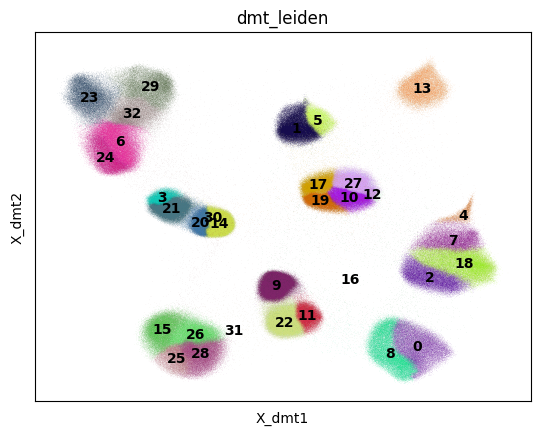

In [43]:
sc.pl.embedding(adata, basis = 'X_dmt',color = 'dmt_leiden', legend_loc = 'on data')

In [9]:
dic = {
    '0': 'mh_0',
    '1': 'mh_1',
    '2': 'mh_2',
    '3': 'mh_3',
    '4': 'mh_4',
    '5': 'mh_5',
    '6': 'mh_1',
    '7': 'mh_6',
    '8': 'mh_0',
    '9': 'mh_6',
    '10': 'mh_7',
    '11': 'mh_8',
    '12': 'mh_9',
    '13': 'mh_10',
    '14': 'mh_9',
    '15': 'mh_11',
    '16': 'mh_10',
    '17': 'mh_12',
    '18': 'mh_8',
    '19': 'mh_3',
    '20': 'mh_9',
    '21': 'mh_2',
    '22': 'mh_5',
    '23': 'mh_14',
    '24': 'mh_14',
    '25': 'mh_5',
    '26': 'mh_3',
    '27': 'mh_8',
    '28': 'mh_9',
    '29': 'mh_15',
    '30': 'mh_7',
    '31': 'mh_1',
    '32': 'mh_16',
    '33': 'mh_5',
    '34': 'mh_14',
    '35': 'mh_2',
    '36': 'mh_16',
    '37': 'mh_0',
    '38': 'mh_5',
    '39': 'mh_10',
    '40': 'mh_11',
    '41': 'mh_17',
    '42': 'mh_5',
    '43': 'mh_18',
    '44': 'mh_9',
    '45': 'mh_1',
    '46': 'mh_18',
    '47': 'mh_7',
    '48': 'mh_1',
    '49': 'mh_3',
    '50': 'mh_2',
    '51': 'mh_2',
}
adata.obs['dmt_leiden_merge'] = [dic[i] if i in dic.keys() else i for i in adata.obs['dmt_leiden']]


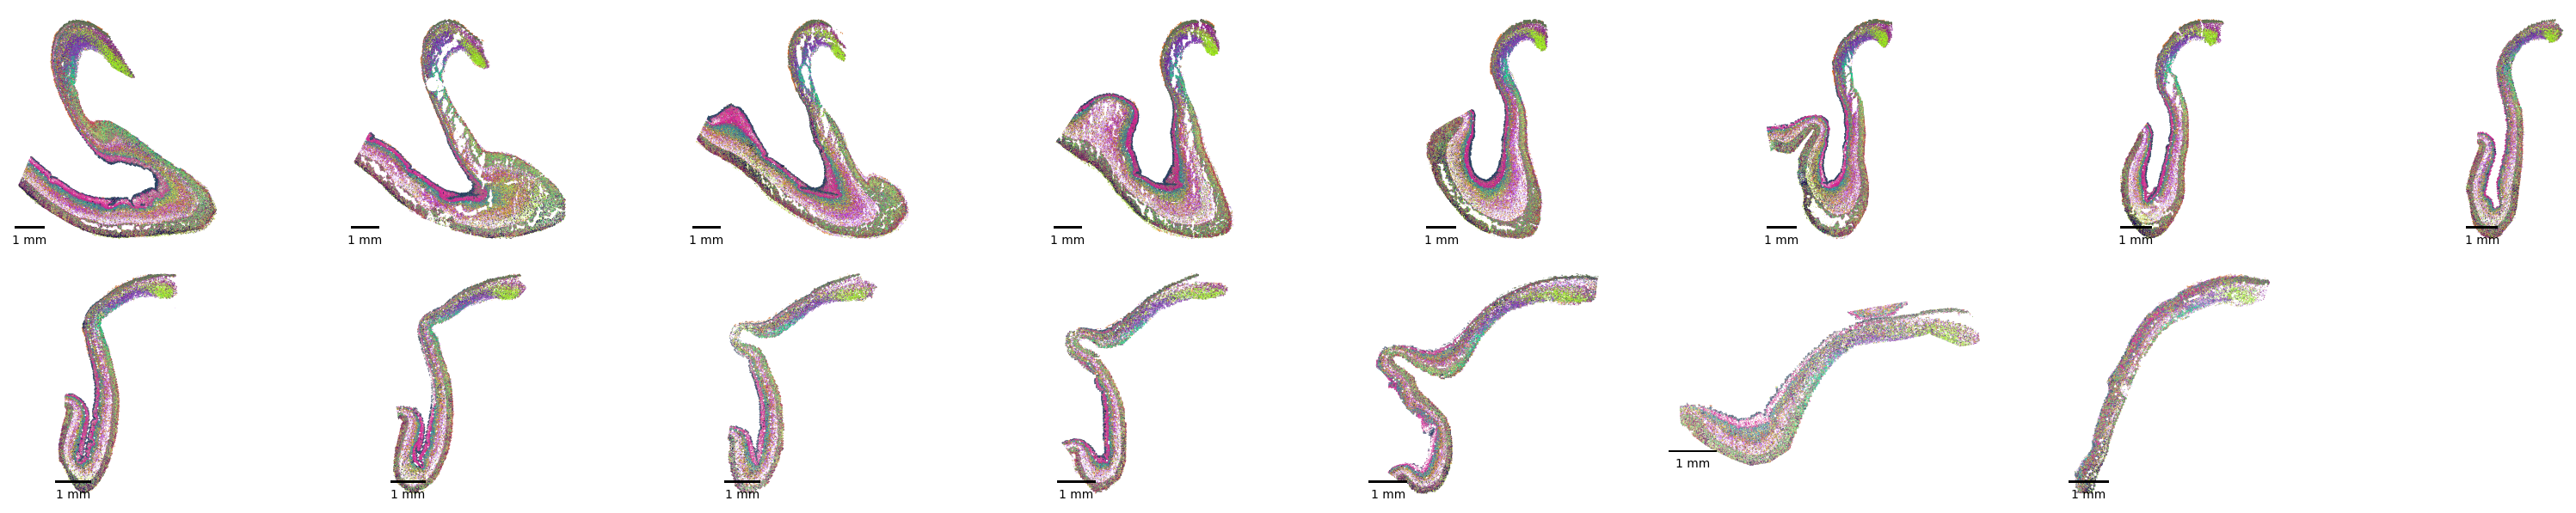

In [45]:
names = [
    '12_B03605F3G5_WT202403310048.h5ad',
    '13_B03612A1C3_WT202403310056.h5ad',
    '14_A03591A1C3_WT202403310045.h5ad',
    '16_A03592A4C6_WT202403310044.h5ad',
    '18_B03602C4D6_WT202405020031.h5ad',
    '20_B03606F3G5_WT202405020032.h5ad',
    '22_B03606C4E6_WT202403310050.h5ad',
    '23_B03609A4D6_WT202404150263.h5ad',
    '27_B03610C1E3_WT202403310051.h5ad',
    '31_B03619A1D3_WT202403310052.h5ad',
    '35_B03619E4G6_WT202403310053.h5ad',
    '39_A03589A1D4_WT202403310046.h5ad',
    '43_A03590E1G4_WT202403310064.h5ad',
    '47_A03593C1F3_WT202403310068.h5ad',
    'B03607C4E6_WT2024071214941.h5ad',
]



fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='dmt_leiden', 
                    show=False, s=1, title='', legend_loc=None, ax=ax)
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  


In [38]:
# for i in set(adata.obs['dmt_leiden_merge']):
#     print(i)
#     fig = plt.figure(figsize=(32, 12))  

#     gs = GridSpec(4, 8, figure=fig)  
#     count = 0
#     for name in names:
#         adata_temp = adata[adata.obs['slice_code'] == name].copy()
#         adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

#         row = (count // 8) + 1  
#         col = count % 8      
#         count +=1
#         ax = fig.add_subplot(gs[row-1, col])
#         sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='dmt_leiden_merge', 
#                         show=False, s=1, palette=colormap, title='', legend_loc=None, ax=ax, groups = i)
#         ax.axis('off')
#         ax.set_aspect('equal')

#         scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
#         ax.add_artist(scalebar)

#     plt.tight_layout()  
#     plt.show()

In [40]:
adata.write('/data/work/05.cluster/FuseMap/0106/mid_hind_latent_embeddings_all_spatial_pretrain/dmt_leiden_20250108_1.h5ad')